# A subspace normal operator

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FiRMLAB-Pisa/mrtoeplitz/blob/main/examples/subspace.ipynb)

`subspace_kernel`: the Gram of a subspace-constrained acquisition in
`rank (rank + 1) / 2` transforms rather than one per frame, checked against
the definition.

In [1]:
try:
    import mrtoeplitz  # noqa: F401
except ImportError:
    %pip install -q "mrtoeplitz[nufft]" matplotlib finufft

In [2]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import torch

import mrtoeplitz as mt


def phantom(n=128):
    """A Shepp-Logan phantom on an n x n grid."""
    y, x = np.mgrid[-1 : 1 : n * 1j, -1 : 1 : n * 1j]
    ellipses = [
        # value, centre x, centre y, semi-axis a, semi-axis b, degrees
        (1.0, 0.0, 0.0, 0.69, 0.92, 0),
        (-0.8, 0.0, -0.0184, 0.6624, 0.874, 0),
        (-0.2, 0.22, 0.0, 0.11, 0.31, -18),
        (-0.2, -0.22, 0.0, 0.16, 0.41, 18),
        (0.1, 0.0, 0.35, 0.21, 0.25, 0),
        (0.1, 0.0, 0.1, 0.046, 0.046, 0),
        (0.1, 0.0, -0.1, 0.046, 0.046, 0),
        (0.1, -0.08, -0.605, 0.046, 0.023, 0),
        (0.1, 0.0, -0.606, 0.023, 0.023, 0),
        (0.1, 0.06, -0.605, 0.023, 0.046, 0),
    ]
    image = np.zeros((n, n))
    for value, cx, cy, a, b, degrees in ellipses:
        angle = np.deg2rad(degrees)
        xr = (x - cx) * np.cos(angle) + (y - cy) * np.sin(angle)
        yr = -(x - cx) * np.sin(angle) + (y - cy) * np.cos(angle)
        image[(xr / a) ** 2 + (yr / b) ** 2 <= 1.0] += value
    return image


n, rank, n_frames = 64, 4, 48
n_spokes, n_samples = 13, 128

# A fingerprinting-like scan: every frame is the same spokes rotated by the
# golden angle, so no two frames share a trajectory.
base_angles = np.pi * np.arange(n_spokes) / n_spokes
radius = np.linspace(-0.5, 0.5, n_samples, endpoint=False)


def spokes(offset):
    angles = base_angles + offset
    return np.stack(
        [np.outer(np.cos(angles), radius), np.outer(np.sin(angles), radius)], axis=-1
    ).astype(np.float32)


golden = np.pi * (np.arange(n_frames) * (np.sqrt(5) - 1) / 2 % 1.0)
trajectory = np.stack([spokes(offset) for offset in golden])

# A subspace basis: the leading components of a signal dictionary. Any
# orthonormal set will do here -- what matters is the shape.
rng = np.random.default_rng(0)
dictionary = np.exp(
    -np.outer(np.arange(n_frames), np.linspace(0.01, 0.2, 64))
).astype(np.float32)
# The left singular vectors span the frame axis, which is the axis the
# basis has to live on.
basis = np.linalg.svd(dictionary, full_matrices=False)[0][:, :rank].T.astype(
    np.float32
)

print(f"trajectory {trajectory.shape} (frames, shots, points, axes)")
print(f"basis {basis.shape} (rank, frames)")

trajectory (48, 13, 128, 2) (frames, shots, points, axes)
basis (4, 48) (rank, frames)


## One transform per basis pair

A subspace normal is not one normal per frame. Expanding the definition, the
frames collapse into `rank (rank + 1) / 2` gridding transforms — one per pair
of basis vectors, over every frame's samples at once. For a fingerprinting
scan with a thousand frames and a rank of four, that is ten transforms rather
than a thousand.

`trajectory` is `(shots, points, axes)` when every frame shares one and
`(frames, shots, points, axes)` when they differ; `basis` is `(frames, rank)`
or its transpose. The frames axis is contrasts for qMRI and time for a
dynamic scan, and nothing here needs to know which.

In [3]:
kernel = mt.subspace_kernel(trajectory, basis, (n, n))
print(kernel)

pairs = rank * (rank + 1) // 2
print(f"rank {rank} costs {pairs} gridding transforms, not {n_frames} -- one per")
print("basis pair, over every frame's samples at once.")
print(f"stored {kernel.storage_nbytes / 2**20:.2f} MiB of a dense "
      f"{kernel.dense_nbytes / 2**20:.2f} MiB ({kernel.compression_ratio:.2f}x)")

PolyphaseToeplitzKernel(rank=4, image_shape=(64, 64), components=4, compression=3.26x)
rank 4 costs 10 gridding transforms, not 48 -- one per
basis pair, over every frame's samples at once.
stored 0.61 MiB of a dense 2.00 MiB (3.26x)


## Is it the subspace Gram?

The reference is the definition, run the slow way: expand the coefficients
into every frame, grid that frame with raw FINUFFT, project back onto the
basis. Forty-eight frames, one at a time.

In [4]:
import finufft


def frame_gram(frame, x):
    """``A_t^H A_t x`` for one frame, with raw FINUFFT."""
    points = np.ascontiguousarray(
        trajectory[frame].reshape(-1, 2).astype(np.float64) * 2 * np.pi
    )
    columns = [np.ascontiguousarray(points[:, axis]) for axis in range(2)]
    forward = finufft.Plan(2, (n, n), isign=-1, eps=1e-9, dtype="complex128")
    forward.setpts(*columns)
    adjoint = finufft.Plan(1, (n, n), isign=+1, eps=1e-9, dtype="complex128")
    adjoint.setpts(*columns)
    return adjoint.execute(forward.execute(np.asarray(x, dtype=np.complex128))) / (
        2 * n
    ) ** 2


def exact_subspace_gram(coefficients):
    """The definition: expand to every frame, grid it, project back."""
    out = np.zeros_like(coefficients)
    for frame in range(n_frames):
        expanded = sum(basis[i, frame] * coefficients[i] for i in range(rank))
        back = frame_gram(frame, expanded)
        for j in range(rank):
            out[j] += np.conj(basis[j, frame]) * back
    return out


coefficients = np.stack(
    [phantom(n) * weight for weight in (1.0, 0.6, -0.3, 0.15)]
).astype(np.complex64)

truth = exact_subspace_gram(coefficients)
fast = kernel(torch.as_tensor(coefficients)[None])[0].numpy()
error = np.linalg.norm(fast - truth) / np.linalg.norm(truth)
print(f"relative error against the exact subspace Gram: {error:.2e}")

relative error against the exact subspace Gram: 1.75e-05


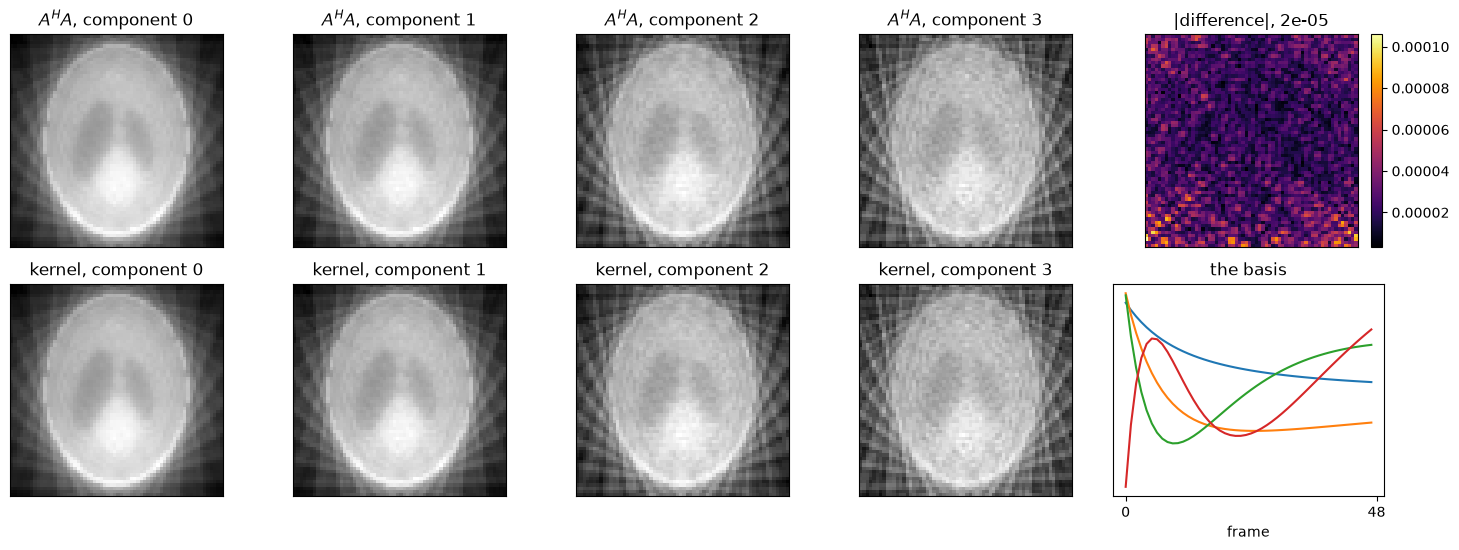

In [5]:
fig, axes = plt.subplots(2, rank + 1, figsize=(3 * (rank + 1), 5.6))
for component in range(rank):
    axes[0, component].imshow(np.abs(truth[component]), cmap="gray")
    axes[0, component].set_title(f"$A^H A$, component {component}")
    axes[1, component].imshow(np.abs(fast[component]), cmap="gray")
    axes[1, component].set_title(f"kernel, component {component}")
for axis in axes.ravel():
    axis.set_xticks([])
    axis.set_yticks([])

shown = axes[0, rank].imshow(
    np.abs(fast - truth).sum(0) / np.abs(truth).max(), cmap="inferno"
)
axes[0, rank].set_title(f"|difference|, {error:.0e}")
fig.colorbar(shown, ax=axes[0, rank], fraction=0.046)
axes[1, rank].plot(basis.T)
axes[1, rank].set_title("the basis")
axes[1, rank].set_xlabel("frame")
axes[1, rank].set_xticks([0, n_frames])
axes[1, rank].set_yticks([])
fig.tight_layout()

In [6]:
# Written only when the notebook runs inside a clone, and it is what the
# README shows -- so the figure in the README is always this cell's output.
figures = Path("figures")
if figures.is_dir():
    fig.savefig(figures / "subspace.png", dpi=110, bbox_inches="tight")

## Frames that share a trajectory

Grouping happens before any gridding, so what the build costs follows the
number of *distinct* trajectories, not the number of frames.

In [7]:
# A scan whose frames cycle through a handful of rotations is a different
# problem: the frames are grouped by trajectory first, so a repeated rotation
# is gridded once however many frames use it.
def time_build(traj):
    start = perf_counter()
    mt.subspace_kernel(traj, basis, (n, n))
    return perf_counter() - start


cycled = np.stack([spokes(golden[index % 4]) for index in range(n_frames)])
distinct = time_build(trajectory)
repeated = time_build(cycled)
print(f"{n_frames} distinct trajectories: {1e3 * distinct:6.0f} ms")
print(f"{n_frames} frames over 4 of them: {1e3 * repeated:6.0f} ms  "
      f"({distinct / repeated:.1f}x)")

48 distinct trajectories:    174 ms
48 frames over 4 of them:    112 ms  (1.6x)
